# Final Exam (part 2) - Computational Physics I

### Deadline: Thursday 5 June 2025 (by 23h59)
### Credits: 10 points

### Please keep the structure provided below and submit an organised notebook with clear answers to each item.

## Name: Silva Alejandro

## 2. Monte Carlo simulations: Cosmology (10 points) 

Supernovae type Ia (SN Ia) are very energetic astronomical explosions, which have a very similar intrinsic known brightness (i.e. they have a very similar absolute magnitude $M$), so they can be used as cosmological "standard candles" to measure the luminosity distance, $d$, as a function of redshift, $z$:

\begin{equation}
d=\frac{cz}{H_0}
\end{equation}

where $c$ is the speed of light and $H_0$ is the Hubble constant. Since they have similar absolute magnitudes $M$, we can estimate distances by comparing how bright or faint they appear on the sky as indicated by the measured apparent magnitude, $m$, which does differ:

\begin{equation}
m=M+5\log\left(\frac{d}{\rm Mpc}\right)+25
\end{equation}

Higher $m$ values imply objects are fainter; lower $m$ values imply objects are brighter. Same for $M$. Unfortunately, selection effects associated with instrumental limitations can bias our measurements. For example, far-away SN Ia can be so faint that they may not be detectable, so the sample will be biased towards brighter objects. In the equation above $\rm Mpc$ stands for Mega parsecs, which are distance units used in cosmology.

**Therefore, to understand selection bias, we want to simulate this effect using a Monte Carlo simulation.**

The purpose of this problem is to determine the bias as a function of redshift for a sample of objects (SN Ia) via a Monte Carlo calculation. To set up your simulation, assume that:

- $H_0 = 70\,\rm km\,s^{-1}\,Mpc^{-1}$

- the absolute magnitude of SN Ia $M=-19.5\,\rm mag$.

- your supernova search will be able to detect $100$% of objects as faint as $m=18.5\,\rm mag$, and none fainter. 

### Requirements
The following libraries are required to run this notebook.

In [1]:
#  Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

In [2]:
# Set plots style
plt.style.use(['science', 'notebook', 'no-latex'])

### (a) Write a python function to generate $N$ Gaussian random variables with mean $\langle M\rangle=-19.5\,\rm mag$ and different standard deviations ($\sigma_M=0.1$, $0.3$, and $0.6\,\rm mag$).

In [3]:
# We'll use a lambda function
# This function generates N random numbers from a Gaussian distribution
# with mean mu and standard deviation sigma.
rand_gaussian = lambda mu, sigma, N: np.random.normal(mu, sigma, N)

### (b) Make $3$ plots of $M$ versus $N$, where $N$ is the number of generated objects, one for each $\sigma_M$.

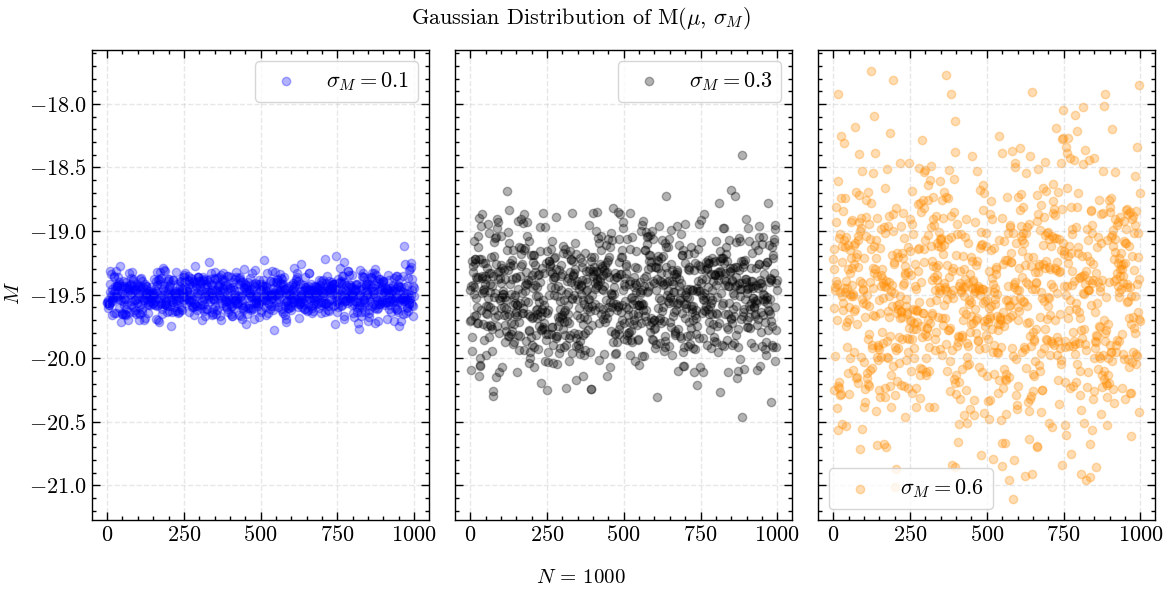

In [4]:
# Fix N
N = 1000
# Fix the mean
mu = -19.5

# Generate objects
obj_1 = rand_gaussian(mu, 0.1, N)
obj_2 = rand_gaussian(mu, 0.3, N)
obj_3 = rand_gaussian(mu, 0.6, N)
# Safe check
#print(obj_1.shape)
#N vector
N_vec = np.arange(N)

# Plotting
fig, ax = plt.subplots(1, 3, figsize=(12, 6), sharey=True) # 1 row, 3 columns
fig.suptitle(r"Gaussian Distribution of M($\mu$, $\sigma_M$)", fontsize=16)
fig.supxlabel(rf"$N$ = {N}", fontsize = 15)
fig.supylabel(r"$M$", fontsize = 15)
ax[0].scatter(N_vec, obj_1, alpha=0.3, color = 'blue', label=r"$\sigma_M = 0.1$")
ax[0].grid(True, linestyle='--', alpha=0.3)
ax[0].legend(frameon=True)

ax[1].scatter(N_vec, obj_2, alpha=0.3, color = 'black', label=r"$\sigma_M = 0.3$")
ax[1].grid(True, linestyle='--', alpha=0.3)
ax[1].legend(frameon=True)

ax[2].scatter(N_vec, obj_3, alpha=0.3, color = 'darkorange', label=r"$\sigma_M = 0.6$")
ax[2].grid(True, linestyle='--', alpha=0.3)
ax[2].legend(frameon=True)

plt.tight_layout()
plt.show()
plt.close()

### (c) Write a python function to calculate and return:

- the luminosity distances, $d$, in $\rm Mpc$ given redshifts between $z=0$ and $z=0.1$.

- the apparent magnitudes, $m$, for the same redshift range.

In [5]:
def calcs_M(M, z):
    """
    This function computes the luminosity distances d in Mpc, given a redshift z. It also computes the\
    apparent magnitudes m.
    ---------------------------
    Inputs:
    M -> array, generated objects according to the Gaussian distribution.
    z -> array, redshift values.
    ---------------------------
    Outputs:
    m -> array, apparent magnitudes.
    d -> array, luminosity distances.
    ---------------------------
    Author: AlejoS
    Date: 02/06/2025
    """
    # 1. Define constants
    H0 = 70  # Hubble constant in km/(s*Mpc)
    c = 3e5  # approx. speed of light in km/s
    # 2. Compute the luminosity distance
    d = c*z/H0
    # 3. Compute the apparent magnitude
    m = M + 5 * np.log10(d) + 25

    return m, d

### (d) Write a python function that:

- reads the resulting $m$ values from item (c),

- removes values with apparent magnitudes larger than the detection threshold $m=18.5\,\rm mag$, 

- re-calculates the mean observed magnitude $\langle M_{\rm observed}\rangle$ of the SN Ia from the actually detected objects for the same redshift range.

- returns the bias as a function of redshift. The bias in $M$ can be calculated with:

\begin{equation}
|\Delta M|=|\langle M_{\rm observed}\rangle  - \langle M\rangle|
\end{equation}

In [6]:
def bias_redshift(m, mu, z):
    """
    This function computes the bias in the apparent magnitude m with respect to the absolute magnitude M.
    ---------------------------
    Inputs:
    m -> array, apparent magnitudes.
    mu -> float, absolute magnitude.
    z -> array, redshift values.
    ---------------------------
    Output:
    delta_M -> float, bias in the apparent magnitude.
    ---------------------------
    Author: AlejoS
    Date: 02/06/2025
    """
    # Compute d, again
    H0 = 70  # Hubble constant in km/(s*Mpc)
    c = 3e5  # approx. speed of light in km/s
    # 2. Compute the luminosity distance
    d = c*z/H0

    # Define detection threshold
    m_threshold = m < 18.5
    # Remove fainter objects
    m_modified = m[m_threshold] #fainter objects have m > m_threshold
    # Recalculate the observed magnitude
    M_obs = m_modified - 5*np.log10(d) - 25
    # Compute the difference
    delta_M = np.abs(np.mean(M_obs) - mu)

    return delta_M

### (e) Make $3$ plots of $m$ versus $N$, where $N$ is the number of generated objects, one for each $\sigma_M=0.1$, $0.3$, and $0.6\,\rm mag$, showing the detection threshold and colouring distinctly the objects that would not be detected.

In [7]:
# Generate redshift values
z = np.linspace(0.0001, 0.1, N)

In [8]:
# Calling our calculations function to find the apparent magnitude
m1, d1 = calcs_M(obj_1, z)
m2, d2 = calcs_M(obj_2, z)
m3, d3 = calcs_M(obj_3, z)

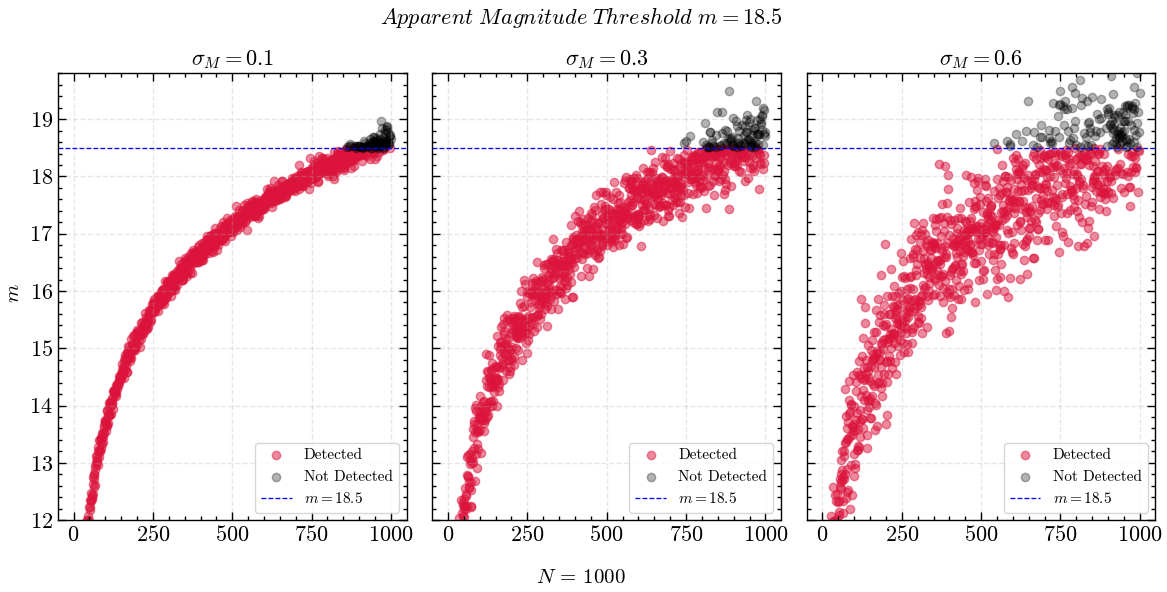

In [9]:
# Detecting objects. We define an index.
detected1 = m1 <= 18.5
detected2 = m2 <= 18.5
detected3 = m3 <= 18.5

# Plotting
fig, ax = plt.subplots(1, 3, figsize=(12, 6), sharey = True) # 1 row, 3 columns
# Axes names and figure title
fig.suptitle(r"$Apparent \ Magnitude \ Threshold \ m = 18.5$", fontsize=16)
fig.supxlabel(rf"$N$ = {N}", fontsize = 15)
fig.supylabel(r"$m$", fontsize = 15)
#sigma1
# Detected objects
ax[0].scatter(N_vec[detected1], m1[detected1], alpha=0.5, color = 'crimson', label = "Detected")
# Not detected objects
ax[0].scatter(N_vec[~detected1], m1[~detected1], alpha=0.3, color = 'black', label = "Not Detected")
ax[0].set_title(r"$\sigma_M = 0.1$", fontsize=16)
ax[0].axhline(18.5, color='blue', linestyle='--',linewidth=0.95, label = r"$m = 18.5$")  # Add threshold line
ax[0].grid(True, linestyle='--', alpha=0.3)
ax[0].legend(frameon=True, fontsize=11)
ax[0].set_ylim(12, 19.8)  # Set y-axis limits for better visibility

#sigma2
# Detected objects
ax[1].scatter(N_vec[detected2], m2[detected2], alpha=0.5, color = 'crimson', label = "Detected")
# Not detected objects
ax[1].scatter(N_vec[~detected2], m2[~detected2], alpha=0.3, color = 'black', label = "Not Detected")
ax[1].set_title(r"$\sigma_M = 0.3$", fontsize=16)
ax[1].axhline(18.5, color='blue', linestyle='--',linewidth=0.95, label = r"$m = 18.5$")  # Add threshold line
ax[1].grid(True, linestyle='--', alpha=0.3)
ax[1].legend(frameon=True, fontsize=11)
ax[1].set_ylim(12, 19.8)  # Set y-axis limits for better visibility

#sigma3
# Detected objects
ax[2].scatter(N_vec[detected3], m3[detected3], alpha=0.5, color = 'crimson', label = "Detected")
# Not detected objects
ax[2].scatter(N_vec[~detected3], m3[~detected3], alpha=0.3, color = 'black', label = "Not Detected")
ax[2].set_title(r"$\sigma_M = 0.6$", fontsize=16)
ax[2].axhline(18.5, color='blue', linestyle='--', linewidth=0.95, label = r"$m = 18.5$")  # Add threshold line
ax[2].grid(True, linestyle='--', alpha=0.3)
ax[2].legend(frameon=True, fontsize=11)
ax[2].set_ylim(12, 19.8)  # Set y-axis limits for better visibility

plt.tight_layout()
plt.show()
plt.close()

### (f) Make $3$ plots of $|\Delta M|$ versus $z$, one for each $\sigma_M=0.1$, $0.3$, and $0.6\,\rm mag$.

In [10]:
# Define empty lists
delta1_M_list = []
delta2_M_list = []
delta3_M_list = []

# Loop over the values in z
for z_i in z:
    # Compute apparent magnitudes for each redshift value
    m1, _ = calcs_M(obj_1, z_i)
    m2, _ = calcs_M(obj_2, z_i)
    m3, _ = calcs_M(obj_3, z_i)

    # Compute biases
    delta1_M = bias_redshift(m1, mu, z_i)
    delta2_M = bias_redshift(m2, mu, z_i)
    delta3_M = bias_redshift(m3, mu, z_i)

    # Append results
    delta1_M_list.append(delta1_M)
    delta2_M_list.append(delta2_M)
    delta3_M_list.append(delta3_M)

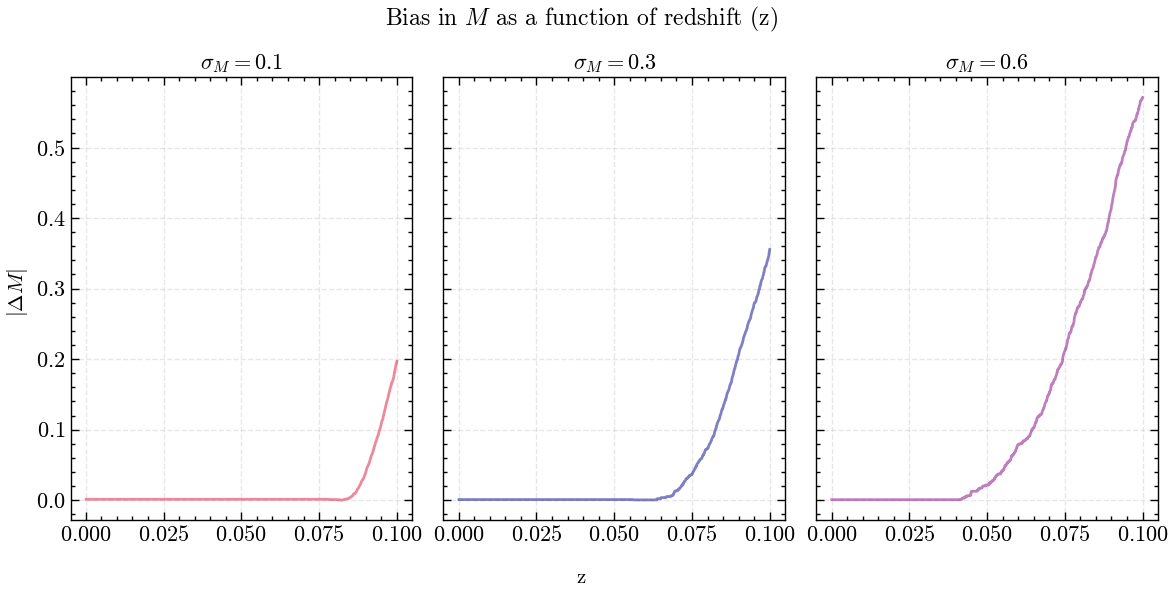

In [11]:
# Plotting
fig, ax = plt.subplots(1, 3, figsize=(12, 6), sharey = True) # 1 row, 3 columns
# Axes names and figure title
fig.suptitle(r"Bias in $M$ as a function of redshift (z)", fontsize=17)
fig.supxlabel(r"z", fontsize = 15)
fig.supylabel(r"$|\Delta M|$", fontsize = 15)
#sigma1
ax[0].plot(z, delta1_M_list, alpha=0.5, color = 'crimson')
ax[0].set_title(r"$\sigma_M = 0.1$", fontsize=16)
ax[0].grid(True, linestyle='--', alpha=0.3)

#sigma2
ax[1].plot(z, delta2_M_list, alpha=0.5, color = 'darkblue')
ax[1].set_title(r"$\sigma_M = 0.3$", fontsize=16)
ax[1].grid(True, linestyle='--', alpha=0.3)

#sigma3
ax[2].plot(z, delta3_M_list, alpha=0.5, color = 'purple')
ax[2].set_title(r"$\sigma_M = 0.6$", fontsize=16)
ax[2].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

### (g) Based on your results, at which redshift does selection bias become important in each case?

For $\sigma_M = 0.1$, we see that at $z = 0.085$ the selection bias begins to increase rapidly.

For $\sigma_M = 0.3$, we see that at $z = 0.065$ the selection bias begins to increase rapidly.

For $\sigma_M = 0.6$, we see that at $z = 0.045$ the selection bias begins to increase rapidly.

It's worth noting that even after running the whole pipeline multiple times, the redshift break points important for bias remained the same.